# Attempt to estimate airflow from heat transfer variables alongside previous tabletop radiator testing

***Note: this methodology is highly flawed with large error and is merely to get a reasonable guess***

Logic:

We have the following variables at our disposal:

- $\dot{m}_{w}$
- $c_{p,w}$
- $\Delta T_{w,rad}$
- From the 3 variables above, we therefore have $Q_{rad}$ via $Q_{rad} = \dot{m}_{w} c_{p,w} \Delta T_{w,rad}$
- $hA_{rad}$ - This comes from benchtop testing. Ideally, we would use a 3-D lookup table with $\dot{m}_{air}$ and $\Delta T_{w,rad}$, but the lack of sufficient flow rate data currently bottlenecks this. Value is approx 241.
- $T_{air,in}$
- c_{p,air}

With $Q$, we can find $\Delta T_{lm}$ via $Q= hA \Delta T_{lm}$. This allows us to obtain $T_{air,out}$ and, by extension, $\Delta T_{air}$. Finally we can find $\dot{m}_{air}$ via $Q= \dot{m}_{air} \Delta T_{air}$.

### Imports

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Opening df, checking temperatures to set deltas correctly, setting known values

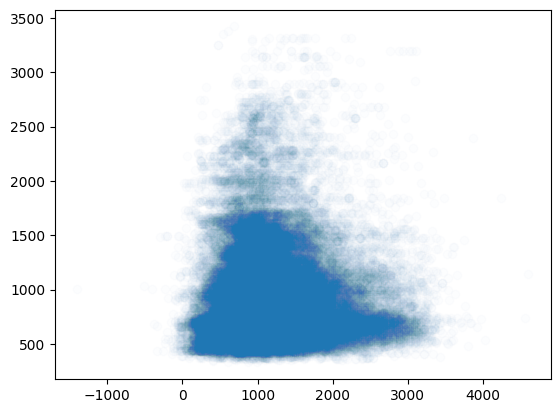

In [31]:
df = pd.read_csv("processed_data/endurance_filtered.csv")
df['left rad delta'] = df['left thermistor'] - df['middle thermistor']
df['motor delta'] = df['left thermistor'] - df['right thermistor']
df['motor inefficiency'] = (5/60) * df['motor delta'] * 4180
df['motor inefficiency'].describe()
df['predicted motor inefficiency'] = (df['motor power (w)']/df['motor efficiency'])-df['motor power (w)']
plt.scatter(df['motor inefficiency'], df['predicted motor inefficiency'], alpha=0.01)
plt.show()

In [32]:
df['left rad q'] = (5/60) * df['left rad delta'] * 4180
hA = 241
df['T_lm'] = df['left rad q']/hA

### Solving LMTD requires iteration

In [33]:
def solve_deltaT2(deltaT1, Tlm, tol=1e-6, max_iter=50):
    # Initial guess: small but positive fraction of deltaT1
    x = deltaT1 * 0.5

    for _ in range(max_iter):
        # Function
        f = (deltaT1 - x) / np.log(deltaT1 / x) - Tlm

        # Derivative
        df = ((np.log(deltaT1 / x)) - (deltaT1 - x) / x) / (np.log(deltaT1 / x)**2)

        # Newton step
        x_new = x - f/df

        # Enforce positive ΔT2
        x_new = np.where(x_new <= 0, x*0.5, x_new)

        # Convergence check
        if np.all(np.abs(x_new - x) < tol):
            return x_new

        x = x_new

    return x  # last iterate if not fully converged

In [35]:
df['deltaT2'] = solve_deltaT2(df['left rad delta'].values, df['T_lm'].values)
df['deltaT2'].describe()

C:\Users\noahk\AppData\Local\Temp\ipykernel_14860\1736687150.py:7: RuntimeWarning: invalid value encountered in divide
  f = (deltaT1 - x) / np.log(deltaT1 / x) - Tlm
C:\Users\noahk\AppData\Local\Temp\ipykernel_14860\1736687150.py:10: RuntimeWarning: invalid value encountered in divide
  df = ((np.log(deltaT1 / x)) - (deltaT1 - x) / x) / (np.log(deltaT1 / x)**2)
C:\Users\noahk\AppData\Local\Temp\ipykernel_14860\1736687150.py:7: RuntimeWarning: invalid value encountered in log
  f = (deltaT1 - x) / np.log(deltaT1 / x) - Tlm
C:\Users\noahk\AppData\Local\Temp\ipykernel_14860\1736687150.py:10: RuntimeWarning: invalid value encountered in log
  df = ((np.log(deltaT1 / x)) - (deltaT1 - x) / x) / (np.log(deltaT1 / x)**2)


count    9.069800e+04
mean     1.562508e-15
std      7.249518e-16
min      1.477699e-17
25%      1.047400e-15
50%      1.429203e-15
75%      1.948846e-15
max      5.911703e-15
Name: deltaT2, dtype: float64